In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import cv2

from czifile import CziFile

from scipy import ndimage as ndi

from skimage import (
    io, filters, morphology, measure, segmentation, exposure
)
from skimage.filters import (
    threshold_otsu, threshold_sauvola, gaussian
)
from skimage.morphology import (
    remove_small_objects, h_maxima, disk, remove_small_holes
)
from skimage.feature import peak_local_max

from multiprocessing import (
    Pool, cpu_count
)

In [2]:
def mip_to_uint8(stack):
    mip = np.max(stack, axis=0)  # MIP по Z

    mip = mip.astype(np.float32)
    mip -= mip.min()
    if mip.max() > 0:
        mip /= mip.max()
    mip *= 255

    return mip.astype(np.uint8)

In [3]:
def process_pair(args):
    
    czi_path, output_dir = args
    
    # Image import
    with CziFile(czi_path) as czi:
        data = czi.asarray()

    data = np.squeeze(data)
    
    ch0_stack = data[0]
    ch1_stack = data[1]

    dapi = mip_to_uint8(ch0_stack)
    fitc = mip_to_uint8(ch1_stack)

    if len(dapi.shape) == 3:
        dapi = cv2.cvtColor(dapi, cv2.COLOR_BGR2GRAY)

    if len(fitc.shape) == 3:
        fitc = cv2.cvtColor(fitc, cv2.COLOR_BGR2GRAY)
    
    name = os.path.splitext(os.path.basename(czi_path))[0]

    # Background correction
    background = filters.gaussian(dapi, sigma=20)
    dapi_corr = exposure.rescale_intensity(dapi - background)
    
    # Adaptive binarization    
    window = 101
    sauvola_thresh = threshold_sauvola(dapi_corr, window_size=window, k=0.15)
    
    binary = dapi_corr > sauvola_thresh
    
    binary = morphology.opening(binary, disk(5))
    binary = remove_small_objects(binary, min_size=120)
    binary = remove_small_holes(binary, area_threshold=120)
     
    # Distance transform + smoothing
    distance = ndi.distance_transform_edt(binary)
    distance = filters.gaussian(distance, sigma=2)
    
    # Local maxima
    coords = peak_local_max(
        distance,
        min_distance=12,
        threshold_abs=0.1,
        labels=binary
    )
    
    markers = np.zeros_like(distance, dtype=int)
    markers[tuple(coords.T)] = np.arange(1, len(coords)+1)
    
    
    # Watershed segmentation
    labels = segmentation.watershed(
        -distance,
        markers,
        mask=binary
    )
    
    # Regions analysis
    regions = measure.regionprops(labels, intensity_image=fitc)

    results = []
    for r in regions:
        results.append({
            "label": r.label,
            "area_px": r.area,
            "mean_fitc": r.mean_intensity,
            "total_int": r.mean_intensity * r.area,
            'solidity': r.solidity,
            'eccentricity': r.eccentricity
        })
    
    if len(results) == 0:
        print(f"⚠️ Нет объектов: {name}")
    
    df = pd.DataFrame(results)
    
    df = df[
        (df.solidity > 0.9) &
        (df.eccentricity < 0.85) &
        (df.area_px < 2 * df.area_px.median())
    ]
    
    # 8. FITC-filtration
    if len(df) > 0:
        fitc_threshold = filters.threshold_otsu(df["mean_fitc"].values)
        df_filtered = df[df["mean_fitc"] > 1 * fitc_threshold]
    else:
        df_filtered = df
    
    
    # Final mask
    final_mask = np.zeros_like(labels)
    
    for label in df_filtered["label"]:
        final_mask[labels == label] = label
    
    
    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    ax[0].imshow(dapi, cmap="gray")
    ax[0].contour(final_mask > 0, colors="red", linewidths=0.5)
    ax[0].set_title("DAPI")
    
    ax[1].imshow(fitc, cmap="gray")
    ax[1].contour(final_mask > 0, colors="red", linewidths=0.5)
    ax[1].set_title("FITC")
    
    for a in ax:
        a.axis("off")
    
    plt.tight_layout()
    plt.savefig(output_dir + '/' + name+'ANNOTATION.png')
    plt.close(fig)

    df_filtered['image'] = czi_path.split('/')[-1]

    print(f"Done: {name}")

    return df_filtered

In [4]:
Meta_data = pd.read_csv('./data/Donors.Metadata.csv')
Meta_data

,samples,age,gender
0,HC_1,62,f
1,HC_2,58,m
2,HC_3,36,f
3,HC_4,59,f
4,HC_5,54,f
5,HC_6,35,m
6,HC_7,41,f
7,HC_8,72,f
8,SZ_1,36,m
9,SZ_2,57,f


In [5]:
Image_files = sorted(glob.glob("./images/*/*.czi"))
Image_files

['../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_1.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_10.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_11.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_12.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_2.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_3.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_4.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_5.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_6.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_7.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_8.czi',
 '../images/HC_1/HC_1_NeuN-488_DAPI_40x_Z0,5_9.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_1.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_10.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_11.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_12.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_2.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_3.czi',
 '../images/HC_2/HC_2_NeuN-488_DAPI_40x_

In [6]:
output_dir = 'results/processed_images'

In [7]:
from multiprocessing import Pool, cpu_count

if __name__ == "__main__":
    os.makedirs(output_dir, exist_ok=True)

    tasks = [(file, output_dir) for file in Image_files]

    n_workers = max(1, 32)

    with Pool(n_workers) as pool:
        results = pool.map(process_pair, tasks)

/tmp/ipykernel_4023614/4256792946.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: HC_5_NeuN-488_DAPI_40x_Z0,5_1


/tmp/ipykernel_4023614/4256792946.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: HC_6_NeuN-488_DAPI_40x_Z0,5_1


/tmp/ipykernel_4023614/4256792946.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


...

Done: SZ_7_NeuN-488_DAPI_40x_Z0,5_12

/tmp/ipykernel_4023614/4256792946.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]



Done: SZ_7_NeuN-488_DAPI_40x_Z0,5_5


/tmp/ipykernel_4023614/4256792946.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: SZ_8_NeuN-488_DAPI_40x_Z0,5_12


In [8]:
Area_df = pd.concat(results)

In [9]:
sample_label = [s.split('-')[0] for s in Area_df.image]
sample_label = [s.replace('_NeuN', '') for s in sample_label]
Area_df['samples'] = sample_label

In [10]:
Area_df = Area_df.merge(Meta_data, on='samples')
Area_df

,label,area_px,mean_fitc,total_int,solidity,eccentricity,image,samples,age,gender
0,8,712.0,62.969101,44834.0,0.946809,0.751464,"HC_1_NeuN-488_DAPI_40x_Z0,5_1.czi",HC_1,62,f
1,16,551.0,126.778584,69855.0,0.943493,0.578328,"HC_1_NeuN-488_DAPI_40x_Z0,5_1.czi",HC_1,62,f
2,18,455.0,149.479121,68013.0,0.917339,0.479052,"HC_1_NeuN-488_DAPI_40x_Z0,5_1.czi",HC_1,62,f
3,20,533.0,89.181989,47534.0,0.950089,0.734837,"HC_1_NeuN-488_DAPI_40x_Z0,5_1.czi",HC_1,62,f
4,22,479.0,122.899791,58869.0,0.937378,0.407782,"HC_1_NeuN-488_DAPI_40x_Z0,5_1.czi",HC_1,62,f
...,...,...,...,...,...,...,...,...,...,...
4510,84,447.0,123.373602,55148.0,0.959227,0.826168,"SZ_8_NeuN-488_DAPI_40x_Z0,5_9.czi",SZ_8,72,m
4511,85,219.0,119.082192,26079.0,0.924051,0.789528,"SZ_8_NeuN-488_DAPI_40x_Z0,5_9.czi",SZ_8,72,m
4512,86,143.0,79.321678,11343.0,0.940789,0.629881,"SZ_8_NeuN-488_DAPI_40x_Z0,5_9.czi",SZ_8,72,m
4513,89,138.0,158.724638,21904.0,0.938776,0.666508,"SZ_8_NeuN-488_DAPI_40x_Z0,5_9.czi",SZ_8,72,m


In [11]:
Area_df.loc[Area_df['age'] < 50, 'age_group'] = 'young'
Area_df.loc[Area_df['age'] >= 50, 'age_group'] = 'old'

In [12]:
Area_df.loc[Area_df.samples.str.contains('SZ'), 'status'] = 'SZ'
Area_df.loc[Area_df.samples.str.contains('HC'), 'status'] = 'HC'

In [13]:
pixel_area = 0.312**2 #from CZI metadata

In [14]:
Area_df['area_umsq'] = Area_df.area_px * pixel_area

In [15]:
Area_df.to_csv('results/NuclearArea.csv')

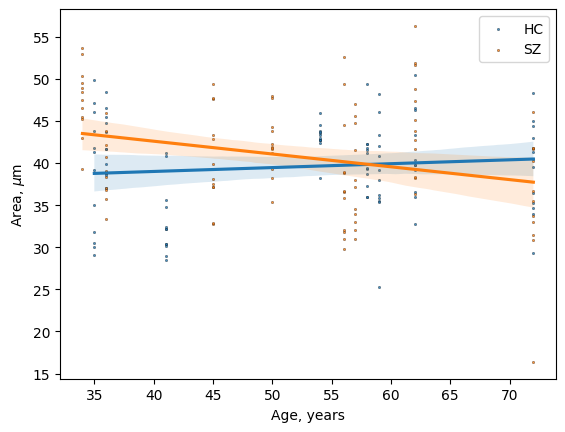

In [16]:
import seaborn as sns

df_image = Area_df.groupby(['samples','image','status','age'])['area_umsq'].mean().reset_index()

sns.regplot(data=df_image.query('status == "HC"'), x='age', y='area_umsq', 
            scatter_kws={"edgecolor": "black", 's':3, 'linewidth':0.25}, label='HC')
sns.regplot(data=df_image.query('status == "SZ"'), x='age', y='area_umsq', 
            scatter_kws={"edgecolor": "black", 's':3, 'linewidth':0.25}, label='SZ')
plt.xlabel('Age, years')
plt.ylabel('Area, $\mu$m')
plt.legend()

<Axes: xlabel='overall_group', ylabel='area_umsq'>

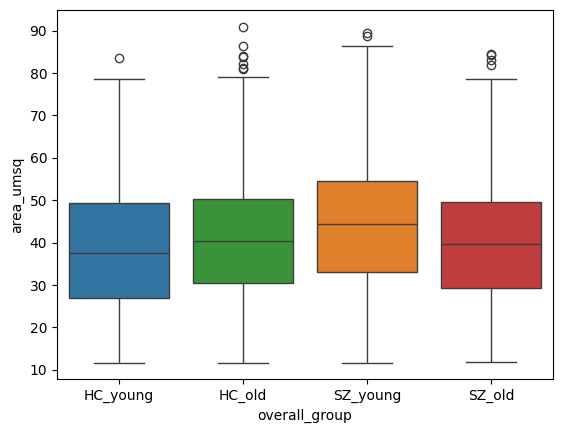

In [17]:
Area_df['overall_group'] = Area_df.status + '_' + Area_df.age_group
sns.boxplot(data=Area_df, x='overall_group', y='area_umsq', hue='overall_group', 
            order=["HC_young", "HC_old", "SZ_young", "SZ_old"], 
            hue_order = ["HC_young", 'SZ_young', "HC_old", "SZ_old"])
